In [51]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\priva\anaconda3\envs\default_3_10\python.exe
3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


In [52]:
!{sys.executable} -m pip install matplotlib

In [53]:
import  pandas as pd
import matplotlib.pyplot as plt

In [54]:

df = pd.read_csv("data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Dataset Problem:
- Data chưa được chuẩn hoá

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [56]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [57]:
# chuẩn hoá tên các cột
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [58]:
df.duplicated().sum()

0

In [59]:
# Null report: count + tỷ lệ % + dtype
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "số_null": null_counts,
    "null_pct (%)": null_pct,
    "dtype": df.dtypes
})

print(f"Tổng số dòng: {len(df)}")
print(f"Số cột có null: {(null_counts > 0).sum()}\n")
missing_report

Tổng số dòng: 9994
Số cột có null: 0



,số_null,null_pct (%),dtype
row_id,0,0.0,int64
order_id,0,0.0,object
order_date,0,0.0,object
ship_date,0,0.0,object
ship_mode,0,0.0,object
customer_id,0,0.0,object
customer_name,0,0.0,object
segment,0,0.0,object
country,0,0.0,object
city,0,0.0,object


In [60]:
# Kiểm tra các empty string trong cột object
obj_cols = df.select_dtypes(include="object").columns

empty_str_counts = df[obj_cols].apply(lambda col: col.str.strip().eq("").sum())

pd.DataFrame({
    "empty_string_count": empty_str_counts,
    "empty_pct (%)": (empty_str_counts / len(df) * 100).round(2)
})


,empty_string_count,empty_pct (%)
order_id,0,0.0
order_date,0,0.0
ship_date,0,0.0
ship_mode,0,0.0
customer_id,0,0.0
customer_name,0,0.0
segment,0,0.0
country,0,0.0
city,0,0.0
state,0,0.0


In [61]:
# Check về mặt logic
issues = {}

# check xem ship_date có bị nhỏ hơn order_date không
issues["ship_date < order_date"] = df[df["ship_date"] < df["order_date"]]

# check xem sales có lớn hơn or < 0 không
issues["sales <= 0"] = df[df["sales"] <= 0]

# check xem quantity có > 1 không
issues["quantity < 1"] = df[df["quantity"] < 1]

# check xem Discount ngoài khoảng [0, 1]
issues["discount ngoài [0, 1]"] = df[(df["discount"] < 0) | (df["discount"] > 1)]

# check xem Profit outlier cực âm (dưới mean - 3σ)
profit_mean, profit_std = df["profit"].mean(), df["profit"].std()
issues[f"profit < mean − 3σ  ({profit_mean - 3*profit_std:.1f})"] = df[df["profit"] < profit_mean - 3 * profit_std]

# Tổng hợp
for label, bad_rows in issues.items():
    status = "⚠️  CÓ VẤN ĐỀ" if len(bad_rows) > 0 else "✓  OK"
    print(f"{status} | {label}: {len(bad_rows)} dòng")

⚠️  CÓ VẤN ĐỀ | ship_date < order_date: 1565 dòng
✓  OK | sales <= 0: 0 dòng
✓  OK | quantity < 1: 0 dòng
✓  OK | discount ngoài [0, 1]: 0 dòng
⚠️  CÓ VẤN ĐỀ | profit < mean − 3σ  (-674.1): 37 dòng


- Nhận xét, có 37 dòng profit âm lớn, check xem thử

In [62]:
# Xem thử các dòng đó trông như thế nào
extreme_loss = df[df["profit"] < profit_mean - 3 * profit_std]
extreme_loss[["order_id", "product_name", "category", "sales", "discount", "profit"]].sort_values("profit")


,order_id,product_name,category,sales,discount,profit
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,0.7,-6599.9780
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.980,0.5,-3839.9904
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.584,0.8,-3701.8928
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.985,0.7,-3399.9800
4991,US-2017-122714,Ibico EPK-21 Electric Binding System,Office Supplies,1889.990,0.8,-2929.4845
3151,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,Technology,1799.994,0.7,-2639.9912
5310,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1525.188,0.8,-2287.7820
9639,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4297.644,0.4,-1862.3124
1199,CA-2016-130946,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,0.8,-1850.9464
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,0.5,-1811.0784


- Quang's note: hi mn, e nhận thấy có một số dòng bị âm khá lớn, nhóm mình có thể further discuss xem là drop hay là xử lý thêm nha, e cám ơn

In [63]:
# hướng 1: drop
#df = df[df["profit"] >= profit_mean - 3 * profit_std]  
## hoặc impute
# df.loc[df["profit"] < profit_mean - 3 * profit_std, "profit"] = profit_mean - 3 * profit_std  


- No nulls
- No missing values
- No duplicated values

In [64]:
# chuyển kiểu dữ liệu ngày tháng
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
# xem 5 dòng đầu của 2 cột order_date and ship_date
df[["order_date", "ship_date"]].head()

,order_date,ship_date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [65]:
df.head(10)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


Bộ dữ liệu khá đặc biệt, nếu để y nguyên thì chúng chưa có thuộc tính khoá chính "Toàn bọ khoá chính"
It means:
- Nếu khoá chính chỉ có 1 cột thôi thì ok auto đạt điều kiện
- Nhưng nếu khoá chính được xác định từ nhiều cột thì chúng ta phải kiểm tra sự phụ thuộc.
- Trong bộ dữ liệu này nếu nói khoá chính là Order ID thì không đúng VÌ 1 order có thể chứa nhiều sản phẩm. Nếu nói Product ID là khoá chính cũng không phải vì 1 sản phẩm xuất hiện trong nhiều đơn hàng.
- ...

In [66]:
df.groupby("order_id").size().sort_values(ascending=False).head(10)

order_id
CA-2017-100111    14
CA-2017-157987    12
US-2016-108504    11
CA-2016-165330    11
CA-2016-105732    10
CA-2015-131338    10
US-2015-126977    10
CA-2015-158421     9
CA-2016-145177     9
US-2015-163433     9
dtype: int64

1 mã đơn hàng xuất hiện nhiều lần trong dataset (có nghĩa là 1 đơn hàng k chỉ mua 1 sản phẩm)

In [67]:
'''
 tạo khoá chính tạm thời bằng cách ghép các cột với nhau.
 Ở đây, 1 đơn hàng = nhiều sản phẩm và ngược lại
 Thực tế nếu nói row_id là khoá chính thì cũng không sai, NHƯNG:
    - nếu nói đơn hàng CA-2016-152156 = dòng thứ 2, nhưng nếu hỏi dòng 2000 là gì thì k xác định được
    - Với business understanding thì order và order item khác nhau
=> kết hợp 2 cột này với nhau ổn hơn ^^
'''

df["order_item_id"] = df["order_id"].astype(str) + "_" + df["row_id"].astype(str)

df[["order_item_id", "order_id", "product_id"]].head()

,order_item_id,order_id,product_id
0,CA-2016-152156_1,CA-2016-152156,FUR-BO-10001798
1,CA-2016-152156_2,CA-2016-152156,FUR-CH-10000454
2,CA-2016-138688_3,CA-2016-138688,OFF-LA-10000240
3,US-2015-108966_4,US-2015-108966,FUR-TA-10000577
4,US-2015-108966_5,US-2015-108966,OFF-ST-10000760


In [68]:
# tạo bảng Customers

customers = df[[
    "customer_id",
    "customer_name",
    "segment"
]].drop_duplicates()

customers.head()

,customer_id,customer_name,segment
0,CG-12520,Claire Gute,Consumer
2,DV-13045,Darrin Van Huff,Corporate
3,SO-20335,Sean O'Donnell,Consumer
5,BH-11710,Brosina Hoffman,Consumer
12,AA-10480,Andrew Allen,Consumer


In [69]:
# tạo bảng products

products = df[[
    "product_id",
    "category",
    "sub_category",
    "product_name"
]].drop_duplicates()

products.head()

,product_id,category,sub_category,product_name
0,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


In [70]:
products.groupby("product_id").size().sort_values(ascending=False).head()

product_id
TEC-PH-10001795    2
OFF-BI-10002026    2
OFF-PA-10003022    2
OFF-AR-10001149    2
OFF-PA-10001970    2
dtype: int64

In [71]:
products[
    products["product_id"] == "TEC-PH-10001795"
]

,product_id,category,sub_category,product_name
806,TEC-PH-10001795,Technology,Phones,ClearOne CHATAttach 160 - speaker phone
5513,TEC-PH-10001795,Technology,Phones,RCA H5401RE1 DECT 6.0 4-Line Cordless Handset ...


In [72]:
# tạo bảng locations
locations = df[[
    "country",
    "city",
    "state",
    "postal_code",
    "region"
]].drop_duplicates().reset_index(drop=True)

locations["location_id"] = range(1, len(locations) + 1)

locations = locations[[
    "location_id",
    "country",
    "city",
    "state",
    "postal_code",
    "region"
]]

locations.head()

,location_id,country,city,state,postal_code,region
0,1,United States,Henderson,Kentucky,42420,South
1,2,United States,Los Angeles,California,90036,West
2,3,United States,Fort Lauderdale,Florida,33311,South
3,4,United States,Los Angeles,California,90032,West
4,5,United States,Concord,North Carolina,28027,South


In [73]:
df = df.merge(
    locations,
    on=["country", "city", "state", "postal_code", "region"],
    how="left"
)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,order_item_id,location_id
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,CA-2016-152156_1,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,CA-2016-152156_2,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,CA-2016-138688_3,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,US-2015-108966_4,3
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,US-2015-108966_5,3


In [74]:
# tạo bảng orders
orders = df[[
    "order_id",
    "order_date",
    "ship_date",
    "ship_mode",
    "customer_id",
    "location_id"
]].drop_duplicates()

orders.head()

,order_id,order_date,ship_date,ship_mode,customer_id,location_id
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,1
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,2
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,3
5,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,4
12,CA-2017-114412,2017-04-15,2017-04-20,Standard Class,AA-10480,5


In [75]:
orders["order_id"].is_unique

True

In [76]:
# tạo bảng order_item
order_items = df[[
    "order_item_id",
    "order_id",
    "product_id",
    "sales",
    "quantity",
    "discount",
    "profit"
]]

order_items.head()

,order_item_id,order_id,product_id,sales,quantity,discount,profit
0,CA-2016-152156_1,CA-2016-152156,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2016-152156_2,CA-2016-152156,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2016-138688_3,CA-2016-138688,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2015-108966_4,US-2015-108966,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,US-2015-108966_5,US-2015-108966,OFF-ST-10000760,22.3680,2,0.20,2.5164


In [77]:
order_items["order_item_id"].is_unique

True

In [78]:
print("customers:", customers.shape)
print("products:", products.shape)
print("locations:", locations.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)

customers: (793, 3)
products: (1894, 4)
locations: (632, 6)
orders: (5009, 6)
order_items: (9994, 7)


In [79]:
# xuất thành file CSV:

customers.to_csv("data/customers.csv", index=False)
products.to_csv("data/products.csv", index=False)
locations.to_csv("data/locations.csv", index=False)
orders.to_csv("data/orders.csv", index=False)
order_items.to_csv("data/order_items.csv", index=False)

# [Phạm Văn Trường] Phân tích tình hình kinh doanh năm 2014.
Flow chi tiết: 
- Phân tích tổng doanh thu, lợi nhuận và số lượng khách hàng
- Phân tích doanh thu lợi nhuận theo tháng


In [80]:
# join dữ liệu từ các bảng lại với nhau để phân tích
# Merge Orders and Order Items

sales_2014_df = order_items.merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

sales_2014_df.head()

,order_item_id,order_id,product_id,sales,quantity,discount,profit,order_date
0,CA-2016-152156_1,CA-2016-152156,FUR-BO-10001798,261.9600,2,0.00,41.9136,2016-11-08
1,CA-2016-152156_2,CA-2016-152156,FUR-CH-10000454,731.9400,3,0.00,219.5820,2016-11-08
2,CA-2016-138688_3,CA-2016-138688,OFF-LA-10000240,14.6200,2,0.00,6.8714,2016-06-12
3,US-2015-108966_4,US-2015-108966,FUR-TA-10000577,957.5775,5,0.45,-383.0310,2015-10-11
4,US-2015-108966_5,US-2015-108966,OFF-ST-10000760,22.3680,2,0.20,2.5164,2015-10-11


In [81]:
# lọc dữ liệu năm 2024

sales_2014_df = sales_2014_df[
    sales_2014_df['order_date'].dt.year == 2014
]


sales_2014_df

,order_item_id,order_id,product_id,sales,quantity,discount,profit,order_date
5,CA-2014-115812_6,CA-2014-115812,FUR-FU-10001487,48.860,7,0.0,14.1694,2014-06-09
6,CA-2014-115812_7,CA-2014-115812,OFF-AR-10002833,7.280,4,0.0,1.9656,2014-06-09
7,CA-2014-115812_8,CA-2014-115812,TEC-PH-10002275,907.152,6,0.2,90.7152,2014-06-09
8,CA-2014-115812_9,CA-2014-115812,OFF-BI-10003910,18.504,3,0.2,5.7825,2014-06-09
9,CA-2014-115812_10,CA-2014-115812,OFF-AP-10002892,114.900,5,0.0,34.4700,2014-06-09
...,...,...,...,...,...,...,...,...
9946,CA-2014-111157_9947,CA-2014-111157,TEC-AC-10004353,151.200,3,0.2,32.1300,2014-03-02
9956,US-2014-143287_9957,US-2014-143287,OFF-PA-10001776,46.350,5,0.0,21.7845,2014-11-11
9957,US-2014-143287_9958,US-2014-143287,OFF-PA-10004039,223.920,4,0.0,109.7208,2014-11-11
9958,US-2014-143287_9959,US-2014-143287,OFF-SU-10001574,7.300,2,0.0,2.1900,2014-11-11


In [82]:
# tổng hợp lại doanh thu và lợi nhuận theo tháng
monthly_sales_profit = (
    sales_2014_df
    .groupby(
        sales_2014_df['order_date'].dt.month
    )
    .agg({
        'sales':'sum',
        'profit':'sum'
    })
    .reset_index()
)

monthly_sales_profit

,order_date,sales,profit
0,1,14236.8950,2450.1907
1,2,4519.8920,862.3084
2,3,55691.0090,498.7299
3,4,28295.3450,3488.8352
4,5,23648.2870,2738.7096
5,6,34595.1276,4976.5244
6,7,33946.3930,-841.4826
7,8,27909.4685,5318.1050
8,9,81777.3508,8328.0994
9,10,31453.3930,3448.2573


In [83]:
# tạo dữ liệu theo tháng
month_map = {
    1:'Jan',
    2:'Feb',
    3:'Mar',
    4:'Apr',
    5:'May',
    6:'Jun',
    7:'Jul',
    8:'Aug',
    9:'Sep',
    10:'Oct',
    11:'Nov',
    12:'Dec'
}

monthly_sales_profit['month_name'] = (
    monthly_sales_profit['order_date']
    .map(month_map)
)

monthly_sales_profit

,order_date,sales,profit,month_name
0,1,14236.8950,2450.1907,Jan
1,2,4519.8920,862.3084,Feb
2,3,55691.0090,498.7299,Mar
3,4,28295.3450,3488.8352,Apr
4,5,23648.2870,2738.7096,May
5,6,34595.1276,4976.5244,Jun
6,7,33946.3930,-841.4826,Jul
7,8,27909.4685,5318.1050,Aug
8,9,81777.3508,8328.0994,Sep
9,10,31453.3930,3448.2573,Oct


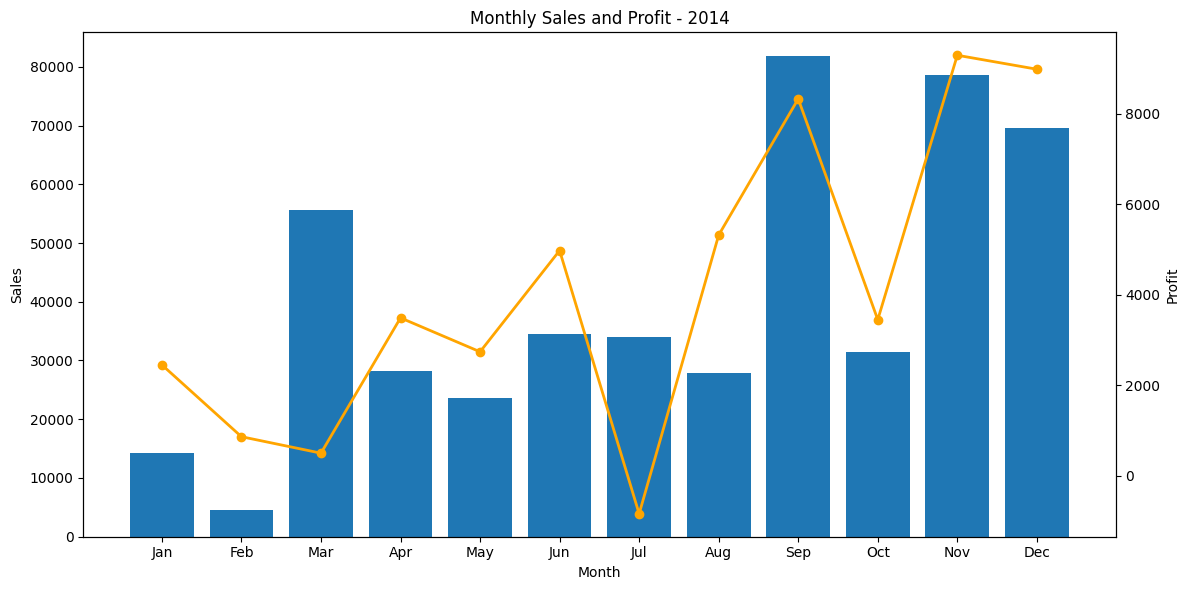

In [84]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue Bar Chart
bars = ax1.bar(
    monthly_sales_profit['month_name'],
    monthly_sales_profit['sales']
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales')
ax1.set_title('Monthly Sales and Profit - 2014')

# Profit Line Chart
ax2 = ax1.twinx()

ax2.plot(
    monthly_sales_profit['month_name'],
    monthly_sales_profit['profit'],
    marker='o',
    linewidth=2,
    color='orange'
)

ax2.set_ylabel('Profit')

plt.tight_layout()
plt.show()

Note: Ở đây chúng ta có thể thấy rằng doanh thu và lợi nhuận ở năm 2014 có khá nhiều biến động. 
Đáng chú ý ở đây: ở tháng 7, tuy doanh thu cũng không phải thấp, thập chí còn nhỉnh hơn 50% số tháng trong năm 2014, nhưng tại tháng 7 ghi nhận mức lợi nhuận âm.

=> Điều gì đã xảy ra ở năm 2014

## Đi vào năm 2014

In [85]:
sales_2014 = df[df['order_date'].dt.year == 2014].copy()
sales_2014.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,order_item_id,location_id
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694,CA-2014-115812_6,4
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656,CA-2014-115812_7,4
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.152,6,0.2,90.7152,CA-2014-115812_8,4
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,0.2,5.7825,CA-2014-115812_9,4
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.900,5,0.0,34.4700,CA-2014-115812_10,4


In [86]:
total_customers = sales_2014['customer_id'].nunique()

total_orders = sales_2014['order_id'].nunique()

total_sales = sales_2014['sales'].sum()

total_profit = sales_2014['profit'].sum()


print(f"Total Customers : {total_customers:,}")
print(f"Total Orders    : {total_orders:,}")
print(f"Total Sales     : ${total_sales:,.2f}")
print(f"Total Profit    : ${total_profit:,.2f}")

Total Customers : 595
Total Orders    : 969
Total Sales     : $484,247.50
Total Profit    : $49,543.97


ở năm 2014 ghi nhận:
- 595 khách hàng
- 969 đơn hàng được bán
- Doanh thu đạt 484,247.50
- Mức lợi nhuận đạt 49,543.97

=> mức biên lợi nhuận đạt ~10%

## Đi sâu vào phân tích tháng có performance bất thường (tháng 7)

In [87]:
july_2014 = df[(df['order_date'].dt.year == 2014) & (df['order_date'].dt.month == 7)].copy()

july_2014.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,order_item_id,location_id
337,338,CA-2014-129924,2014-07-12,2014-07-17,Standard Class,AC-10420,Alyssa Crouse,Corporate,United States,San Francisco,...,OFF-BI-10003314,Office Supplies,Binders,Tuff Stuff Recycled Round Ring Binders,7.712,2,0.2,2.7956,CA-2014-129924_338,35
338,339,CA-2014-129924,2014-07-12,2014-07-17,Standard Class,AC-10420,Alyssa Crouse,Corporate,United States,San Francisco,...,FUR-TA-10004575,Furniture,Tables,Hon 5100 Series Wood Tables,698.352,3,0.2,-17.4588,CA-2014-129924_339,35
372,373,US-2014-119137,2014-07-23,2014-07-27,Standard Class,AG-10900,Arthur Gainer,Consumer,United States,Tucson,...,OFF-BI-10001982,Office Supplies,Binders,Wilson Jones Custom Binder Spines & Labels,8.160,5,0.7,-5.7120,US-2014-119137_373,116
373,374,US-2014-119137,2014-07-23,2014-07-27,Standard Class,AG-10900,Arthur Gainer,Consumer,United States,Tucson,...,TEC-AC-10003911,Technology,Accessories,NETGEAR AC1750 Dual Band Gigabit Smart WiFi Ro...,1023.936,8,0.2,179.1888,US-2014-119137_374,116
374,375,US-2014-119137,2014-07-23,2014-07-27,Standard Class,AG-10900,Arthur Gainer,Consumer,United States,Tucson,...,OFF-AR-10000658,Office Supplies,Art,Newell 324,9.240,1,0.2,0.9240,US-2014-119137_375,116


In [88]:
daily_sales_profit = (july_2014.groupby('order_date').agg(sales=('sales', 'sum'),profit=('profit', 'sum')).reset_index())

daily_sales_profit.head()

,order_date,sales,profit
0,2014-07-01,601.024,75.3332
1,2014-07-02,79.560,22.1508
2,2014-07-04,247.408,83.9448
3,2014-07-05,1444.104,182.7936
4,2014-07-06,1038.472,222.8455


In [89]:
daily_sales_profit['day'] = (daily_sales_profit['order_date'].dt.day)

daily_sales_profit

,order_date,sales,profit,day
0,2014-07-01,601.024,75.3332,1
1,2014-07-02,79.560,22.1508,2
2,2014-07-04,247.408,83.9448,4
3,2014-07-05,1444.104,182.7936,5
4,2014-07-06,1038.472,222.8455,6
5,2014-07-07,241.194,-34.6598,7
6,2014-07-08,763.074,-8.4420,8
7,2014-07-09,265.521,57.2078,9
8,2014-07-11,2187.206,537.7298,11
9,2014-07-12,1960.012,88.4544,12


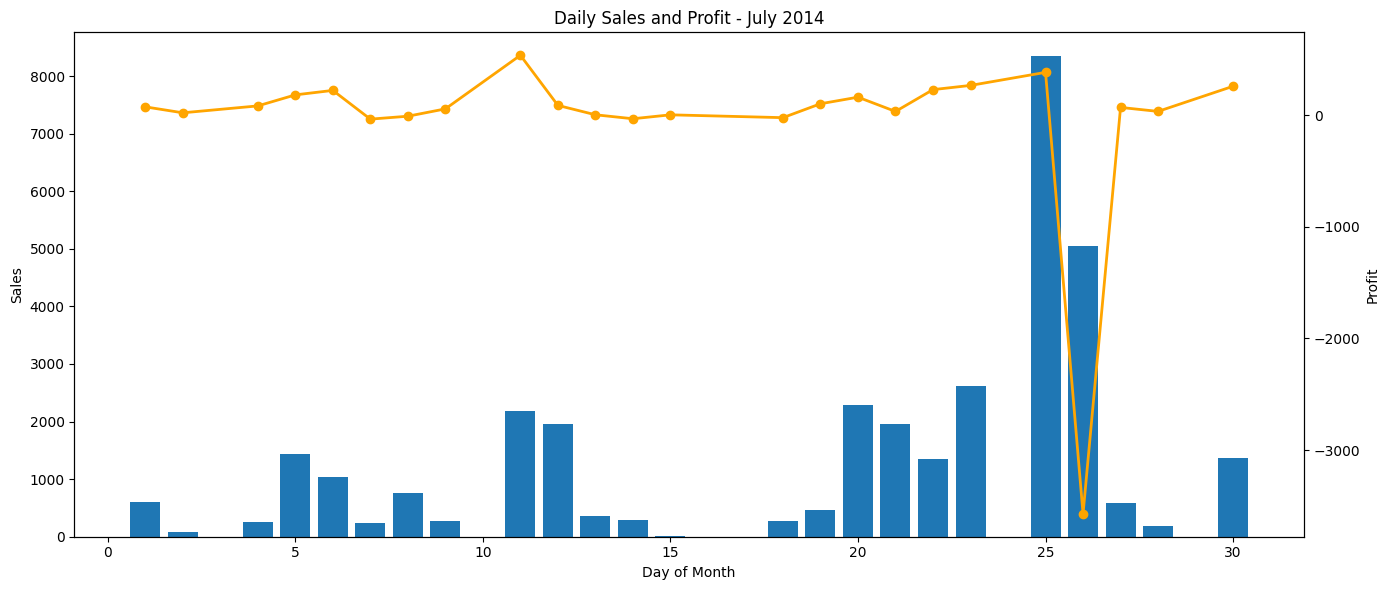

In [90]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Sales
bars = ax1.bar(
    daily_sales_profit['day'],
    daily_sales_profit['sales']
)

ax1.set_xlabel('Day of Month')
ax1.set_ylabel('Sales')
ax1.set_title('Daily Sales and Profit - July 2014')

# Profit
ax2 = ax1.twinx()

ax2.plot(
    daily_sales_profit['day'],
    daily_sales_profit['profit'],
    marker='o',
    linewidth=2,
    color='orange'
)

ax2.set_ylabel('Profit')

plt.tight_layout()
plt.show()

Note: tất cả các ngày trong tháng 7, lợi nhuận đều quanh quẩn mức 0 và có cả những tháng lợi nhuận âm. 
Tuy nhiên, ngày 26 thật sự không hề bình thường

=> đi sâu vào phân tích ngày 26 -> tại sao lại có mức lợi nhuận âm bất thường đến như vậy?

Note: ở đây

In [91]:
print("\nThống kê:")
print(df.describe())


Thống kê:
            row_id                     order_date  \
count  9994.000000                           9994   
mean   4997.500000  2016-04-30 00:07:12.259355648   
min       1.000000            2014-01-03 00:00:00   
25%    2499.250000            2015-05-23 00:00:00   
50%    4997.500000            2016-06-26 00:00:00   
75%    7495.750000            2017-05-14 00:00:00   
max    9994.000000            2017-12-30 00:00:00   
std    2885.163629                            NaN   

                           ship_date   postal_code         sales     quantity  \
count                           9994   9994.000000   9994.000000  9994.000000   
mean   2016-05-03 23:06:58.571142912  55190.379428    229.858001     3.789574   
min              2014-01-07 00:00:00   1040.000000      0.444000     1.000000   
25%              2015-05-27 00:00:00  23223.000000     17.280000     2.000000   
50%              2016-06-29 00:00:00  56430.500000     54.490000     3.000000   
75%              2017-05-

In [92]:
#doanh thu và lợi nhuận tổng
print(f"Tổng sales: {df['sales'].sum()}")
print(f"Tổng profit: {df['profit'].sum()}")

Tổng sales: 2297200.8603000003
Tổng profit: 286397.0217


In [93]:
print("\nTop 10 Products:")
print(
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


Top 10 Products:
product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64


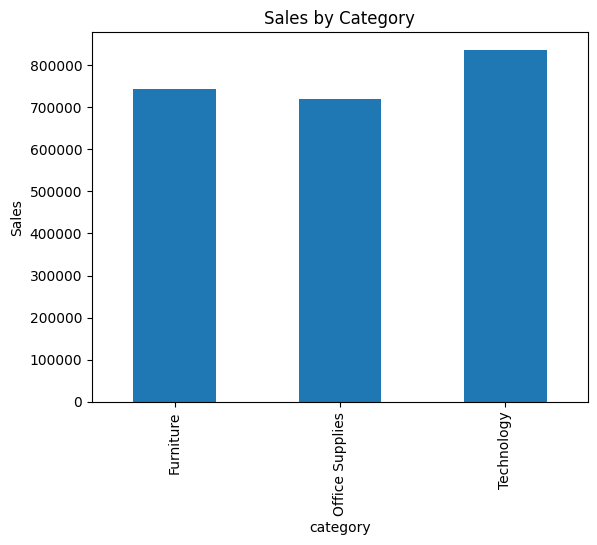

In [94]:
import matplotlib.pyplot as plt

# Doanh thu theo Category
df.groupby("category")["sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

Phân tích dataset theo timeseries

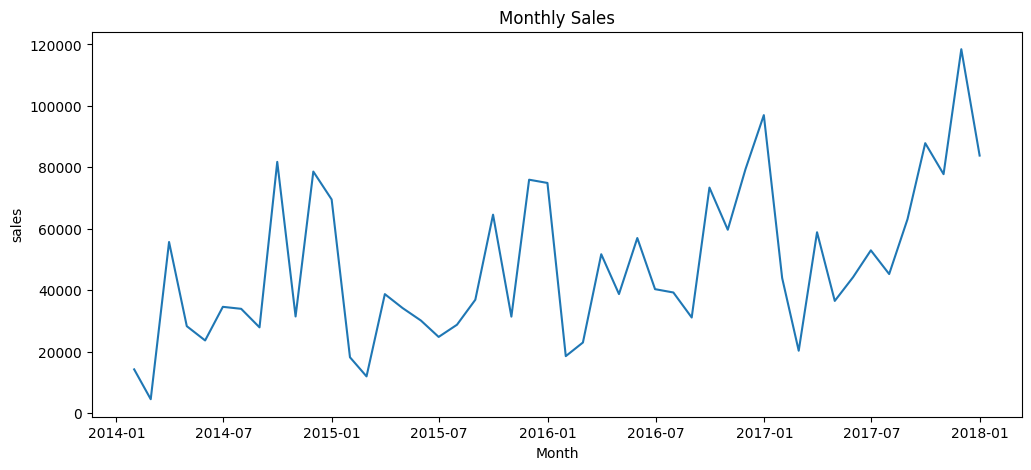

In [95]:
#convert cột order_date từ string sang dạng date time(vì ban đầu order_date là dạng string)
df["order_date"] = pd.to_datetime(df["order_date"])
#gom sales lại theo tháng
monthly_sales = (
    df.groupby(pd.Grouper(key="order_date", freq="M"))["sales"]
      .sum()
      .reset_index()
)
plt.figure(figsize=(12,5))
plt.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"]
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("sales")
plt.show()

nhìn qua biểu đồ ta thấy dự sales thường tăng vào khoảng cuối năm => dự liệu có dạng seasonality


In [96]:
#nhìn sơ qua thì thấy được trend có xu hướng tăng theo năm, biến động mạnh và xu hướng sales tăng đột
#biến vào cuói năm. Có thể do các ngày lễ (blackfriday,giáng sinh?)


1. ĐÁNH GÍA THEO HIỆU XUẤT KINH DOANH 2016 THEO SALES VÀ PROFIT THÔNG QUA MARGIN

In [97]:
df_2016 = df[df['order_date'].dt.year == 2016].copy()
df_2017 = df[df['order_date'].dt.year == 2017].copy()

#tổng sales
sales_2016 = df_2016['sales'].sum()
sales_2017 = df_2017['sales'].sum()

#tổng profit
profit_2016 = df_2016['profit'].sum()
print(f"Sales 2016: {sales_2016}\nSales 2017: {sales_2017}")

Sales 2016: 609205.598
Sales 2017: 733215.2552


In [98]:
#Margin = (profit/sales)*100(margin là lợi nhận thực tế sau khi
#trừ chi phí, thuế, lãi suất,...)
margin_2016 = (profit_2016/sales_2016)*100
margin_2016 = (profit_2016/sales_2016)*100


In [99]:
# fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# # axes[0] là biểu đồ bên trái -> vẽ Sales
# axes[0].bar(['2016', '2017'], [sales_2016, sales_2017], color=['#85B7EB', '#185FA5'])
# axes[0].set_title('Tổng Sales')
# axes[0].set_ylabel('USD')

# # axes[1] là biểu đồ bên phải -> vẽ Profit
# axes[1].bar(['2016', '2017'], [profit_2016, profit_2017], color=['#97C459', '#3B6D11'])
# axes[1].set_title('Tổng Profit')
# axes[1].set_ylabel('USD')

# # tight_layout() tự canh khoảng cách giữa các subplot cho khỏi đè chữ lên nhau
# plt.tight_layout()
# plt.show()

2. ĐÁNH GIÁ PROFIT DỰA TRÊN TỈ LỆ DISCOUNT

In [100]:
# .assign() tạo cột mới an toàn hơn df['cột'] = ... khi làm việc với DataFrame đã lọc
# Nó trả về 1 DataFrame mới có thêm cột đó, không sửa trực tiếp vào df_2016 gốc

bins = [-0.01, 0, 0.2, 0.4, 1.0]
labels = ['0% (không giảm)', '1-20%', '21-40%', '41%+']

df_2016 = df_2016.assign(
    Discount_Band=pd.cut(df_2016['discount'], bins=bins, labels=labels)
)
df_2017 = df_2017.assign(
    Discount_Band=pd.cut(df_2017['discount'], bins=bins, labels=labels)
)

# Kiểm tra cột mới đã có chưa
print(df_2016['Discount_Band'].value_counts().sort_index())

Discount_Band
0% (không giảm)    1248
1-20%               976
21-40%              122
41%+                241
Name: count, dtype: int64


## 2015

In [101]:
# 1. KPI tổng quan hóa
df_2015 = df[df['order_date'].dt.year == 2015].copy()

total_sales  = df_2015['sales'].sum()
total_profit = df_2015['profit'].sum()
margin       = total_profit / total_sales * 100
n_orders     = df_2015['order_id'].nunique()
n_customers  = df_2015['customer_id'].nunique()
aov          = total_sales / n_orders 

print("===== KPI NĂM 2015 =====")
print(f"Tổng Sales      : ${total_sales:,.0f}")
print(f"Tổng Profit     : ${total_profit:,.0f}")
print(f"Profit Margin   : {margin:.2f}%")
print(f"Số đơn hàng     : {n_orders:,}")
print(f"Số khách hàng   : {n_customers:,}")
print(f"Giá trị TB/đơn  : ${aov:,.2f}")

===== KPI NĂM 2015 =====
Tổng Sales      : $470,533
Tổng Profit     : $61,619
Profit Margin   : 13.10%
Số đơn hàng     : 1,038
Số khách hàng   : 573
Giá trị TB/đơn  : $453.31


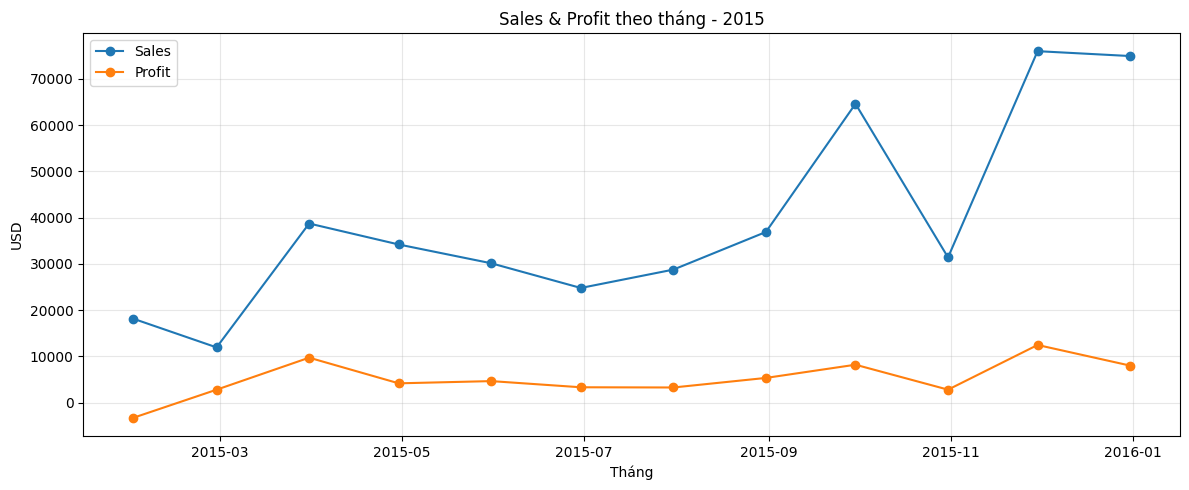

In [102]:
# ===== 2. Xu hướng Sales & Profit theo tháng (2015) =====
monthly_2015 = (
    df_2015.groupby(pd.Grouper(key="order_date", freq="M"))[["sales", "profit"]]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_2015["order_date"], monthly_2015["sales"],  marker="o", label="Sales")
ax.plot(monthly_2015["order_date"], monthly_2015["profit"], marker="o", label="Profit")
ax.set_title("Sales & Profit theo tháng - 2015")
ax.set_xlabel("Tháng")
ax.set_ylabel("USD")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

===== Theo Category =====
                      sales      profit  margin_pct
category                                           
Furniture        170518.237   3015.2029        1.77
Technology       162780.809  33503.8670       20.58
Office Supplies  137233.463  25099.5338       18.29 

===== Sub-Category (sắp theo profit) =====
                   sales      profit  margin_pct
sub_category                                    
Phones        68313.7020  10398.8074       15.22
Accessories   40523.9600  10197.2752       25.16
Copiers       26179.4500   9930.2988       37.93
Binders       37453.0980   7596.6714       20.28
Paper         15287.6380   6570.1700       42.98
Chairs        71734.5290   6228.4161        8.68
Storage       45048.2480   3505.4601        7.78
Furnishings   21089.7120   3051.8189       14.47
Machines      27763.6970   2977.4856       10.72
Appliances    23241.2890   2511.8957       10.81
Envelopes      4512.1880   1960.1906       43.44
Art            6236.8340   1485.

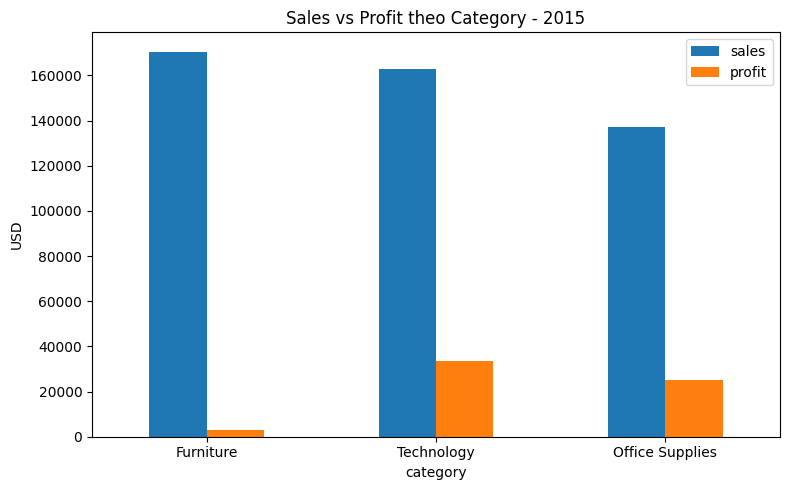

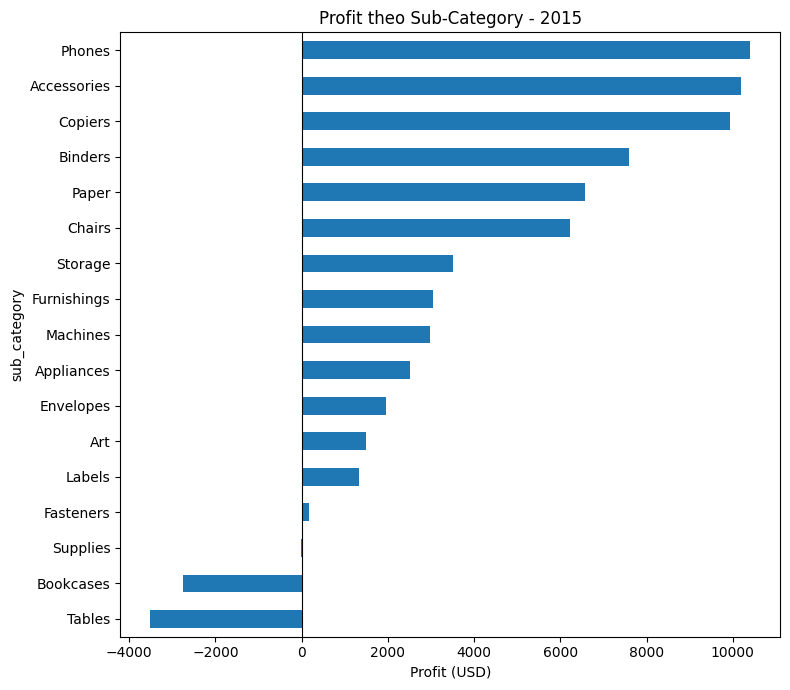

In [103]:
# ===== 3. Hiệu suất theo Category & Sub-Category (2015) =====
cat_2015 = (
    df_2015.groupby("category")[["sales", "profit"]]
    .sum()
    .assign(margin_pct=lambda x: (x["profit"] / x["sales"] * 100).round(2))
    .sort_values("sales", ascending=False)   
)
print("===== Theo Category =====")
print(cat_2015, "\n")

subcat_2015 = (
    df_2015.groupby("sub_category")[["sales", "profit"]]
    .sum()
    .assign(margin_pct=lambda x: (x["profit"] / x["sales"] * 100).round(2))
    .sort_values("profit", ascending=False)
)
print("===== Sub-Category (sắp theo profit) =====")
print(subcat_2015)

# Biểu đồ Sales vs Profit theo Category 
cat_2015[["sales", "profit"]].plot(kind="bar", figsize=(8, 5))
plt.title("Sales vs Profit theo Category - 2015")
plt.ylabel("USD")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Biểu đồ Profit theo Sub-Category 

subcat_2015["profit"].sort_values().plot(kind="barh", figsize=(8, 7))
plt.title("Profit theo Sub-Category - 2015")
plt.xlabel("Profit (USD)")
plt.axvline(0, color="black", linewidth=0.8)   # vạch mốc 0 để thấy nhóm lỗ
plt.tight_layout()
plt.show()

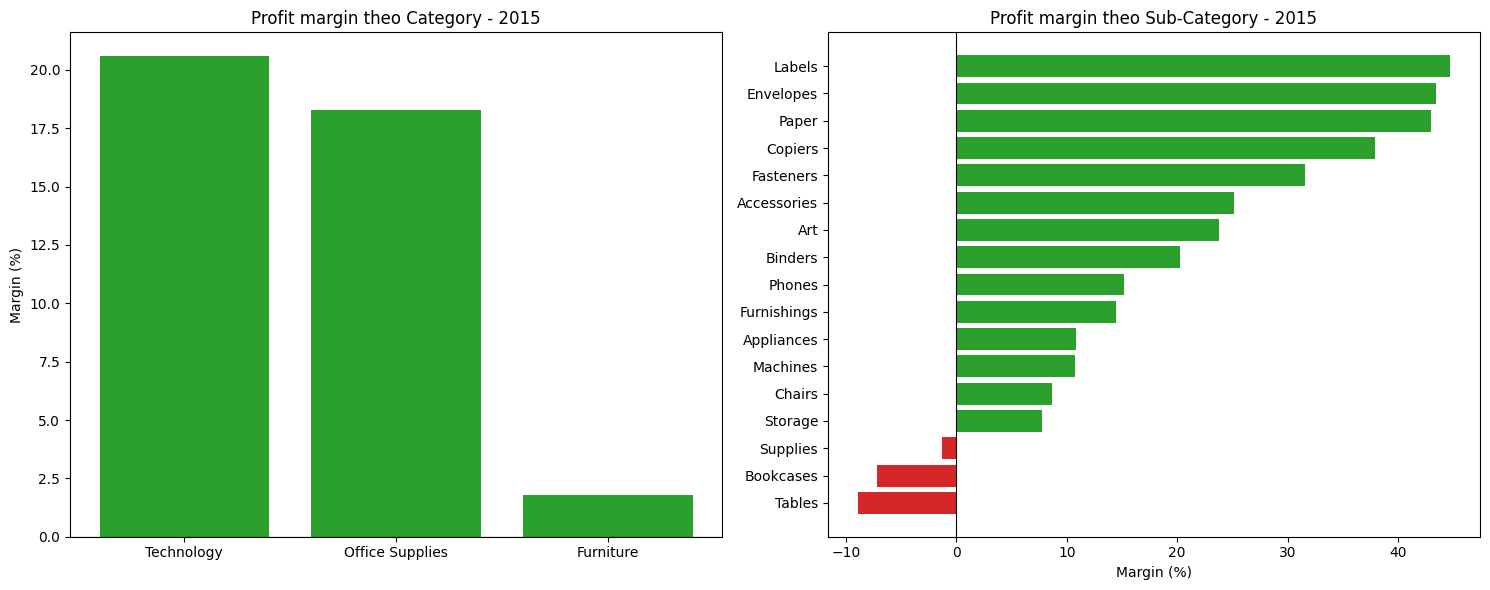

In [104]:
# ===== 3b. Profit margin theo Category & Sub-Category (2015) =====

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cat_margin = cat_2015["margin_pct"].sort_values(ascending=False)
axes[0].bar(cat_margin.index, cat_margin.values,
            color=["#2ca02c" if v >= 0 else "#d62728" for v in cat_margin.values])
axes[0].set_title("Profit margin theo Category - 2015")
axes[0].set_ylabel("Margin (%)")
axes[0].axhline(0, color="black", linewidth=0.8)

# --- Sub-Category: bar ngang, cao nhất ở trên cùng ---
sub_margin = subcat_2015["margin_pct"].sort_values()   # ascending -> cao nằm trên
axes[1].barh(sub_margin.index, sub_margin.values,
             color=["#2ca02c" if v >= 0 else "#d62728" for v in sub_margin.values])
axes[1].set_title("Profit margin theo Sub-Category - 2015")
axes[1].set_xlabel("Margin (%)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

                 so_dong  tong_sales  tong_profit  profit_tb
Discount_Band                                               
0% (không giảm)     1023   226519.85     68870.76      67.32
1-20%                786   180029.45     21153.01      26.91
21-40%                92    41369.66     -8151.47     -88.60
41%+                 201    22613.55    -20253.69    -100.76


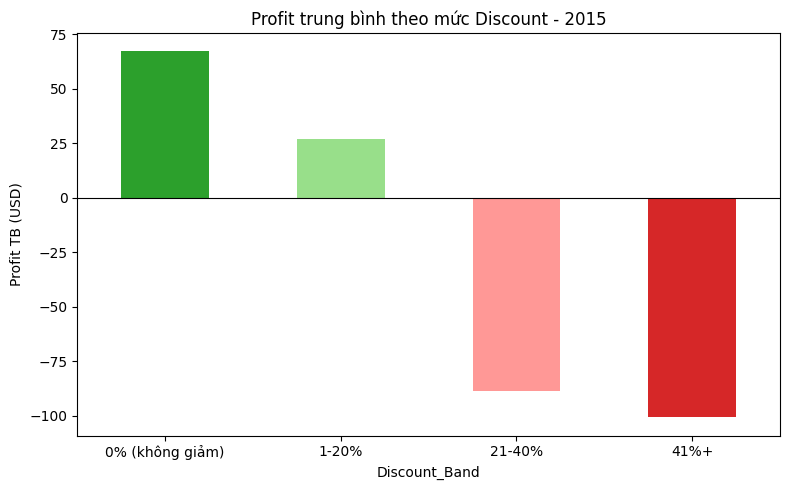

In [105]:
# ===== 4. Ảnh hưởng của Discount đến Profit (2015) =====
# Chia discount thành các band giống phần phân tích 2016/2017
bins   = [-0.01, 0, 0.2, 0.4, 1.0]
labels = ['0% (không giảm)', '1-20%', '21-40%', '41%+']

df_2015 = df_2015.assign(
    Discount_Band=pd.cut(df_2015['discount'], bins=bins, labels=labels)
)

discount_2015 = (
    df_2015.groupby("Discount_Band", observed=True)
    .agg(so_dong=("profit", "size"),
         tong_sales=("sales", "sum"),
         tong_profit=("profit", "sum"),
         profit_tb=("profit", "mean"))
    .round(2)
)
print(discount_2015)

# Profit trung bình theo từng mức discount -> thấy rõ discount cao thì lỗ
df_2015.groupby("Discount_Band", observed=True)["profit"].mean().plot(
    kind="bar", figsize=(8, 5),
    color=["#2ca02c", "#98df8a", "#ff9896", "#d62728"]
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Profit trung bình theo mức Discount - 2015")
plt.ylabel("Profit TB (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

                 tong_sales  tong_profit  margin_pct
Discount_Band                                       
0% (không giảm)   226519.85     68870.76       30.40
1-20%             180029.45     21153.01       11.75
21-40%             41369.66     -8151.47      -19.70
41%+               22613.55    -20253.69      -89.56


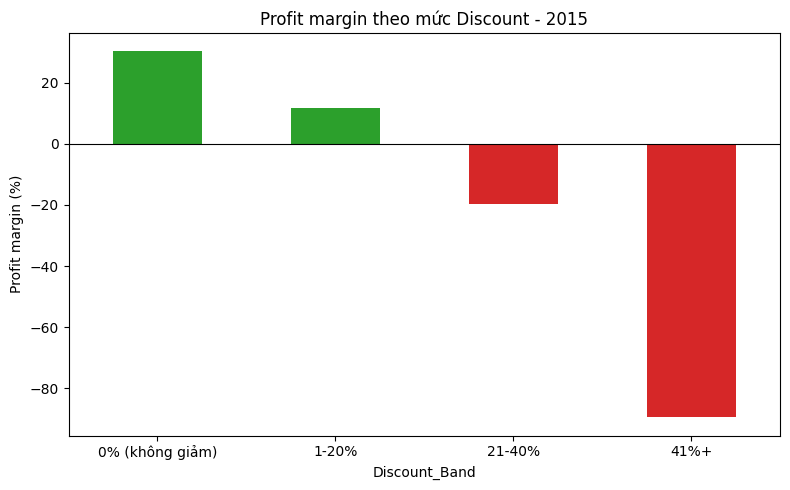

In [106]:
# 4.b Profit margin theo mức discount
discount_2015["margin_pct"] = (
    discount_2015["tong_profit"] / discount_2015["tong_sales"] * 100
).round(2)
print(discount_2015[["tong_sales", "tong_profit", "margin_pct"]])

# Biểu đồ margin theo mức discount (giữ thứ tự 0% -> 41%+)
discount_2015["margin_pct"].plot(
    kind="bar", figsize=(8, 5),
    color=["#2ca02c" if v >= 0 else "#d62728" for v in discount_2015["margin_pct"]]
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Profit margin theo mức Discount - 2015")
plt.ylabel("Profit margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

               sales      profit  margin_pct
region                                      
East     156332.0570  21091.0130       13.49
West     139966.2495  20492.1947       14.64
Central  102874.2220  11716.8020       11.39
South     71359.9805   8318.5940       11.66


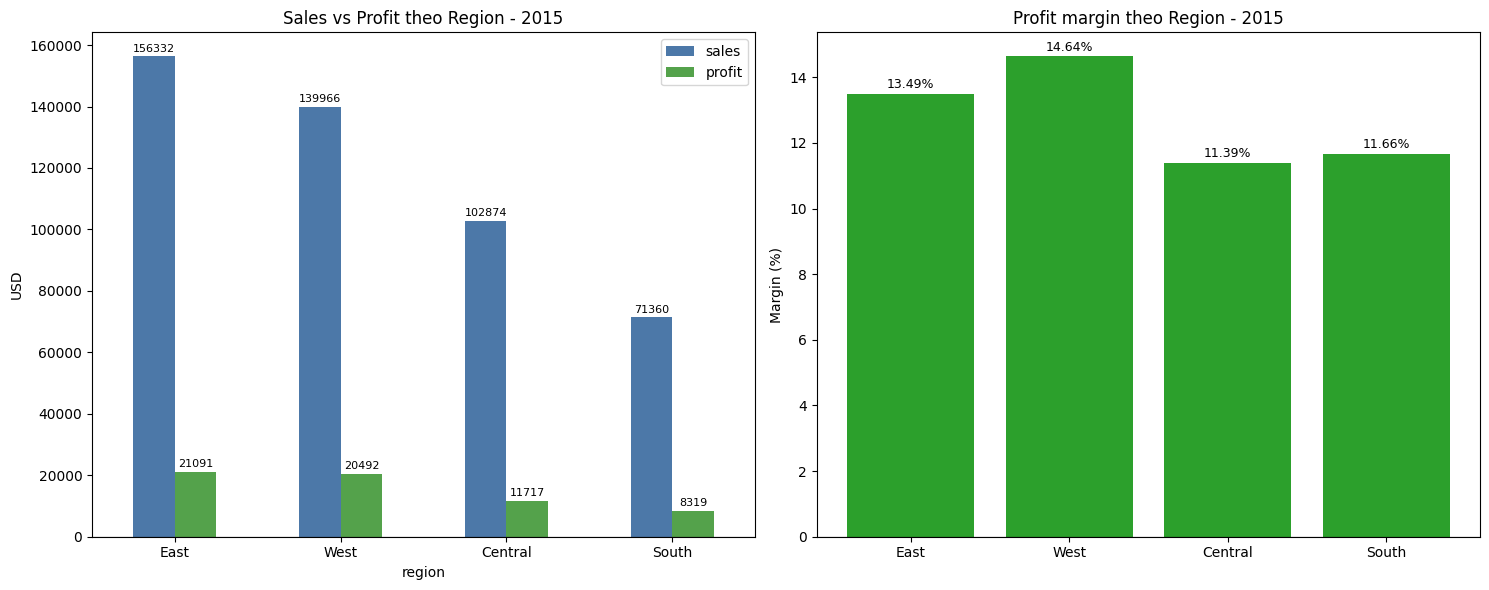

In [107]:
# ===== 5. Hiệu suất theo Region (2015) =====
region_2015 = (
    df_2015.groupby("region")[["sales", "profit"]]
    .sum()
    .assign(margin_pct=lambda x: (x["profit"] / x["sales"] * 100).round(2))
    .sort_values("profit", ascending=False)
)
print(region_2015)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Trái: Sales vs Profit (có số trên từng cột) ---
region_2015[["sales", "profit"]].plot(kind="bar", ax=axes[0], color=["#4C78A8", "#54A24B"])
axes[0].set_title("Sales vs Profit theo Region - 2015")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=0)
axes[0].axhline(0, color="black", linewidth=0.8)
for c in axes[0].containers:                      # ghi số lên cả 2 nhóm cột
    axes[0].bar_label(c, fmt="%.0f", padding=2, fontsize=8)

# --- Phải: Profit margin % (xanh = lãi, đỏ = lỗ) ---
m = region_2015["margin_pct"]
axes[1].bar(m.index, m.values,
            color=["#2ca02c" if v >= 0 else "#d62728" for v in m.values])
axes[1].set_title("Profit margin theo Region - 2015")
axes[1].set_ylabel("Margin (%)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f%%", padding=2, fontsize=9)

plt.tight_layout()
plt.show()

             orders  customers  total_sales  total_profit  margin_pct
segment                                                              
Consumer        535        295  266535.9333    28460.1665       10.68
Corporate       312        165  128757.3069    20688.3248       16.07
Home Office     191        113   75239.2688    12470.1124       16.57


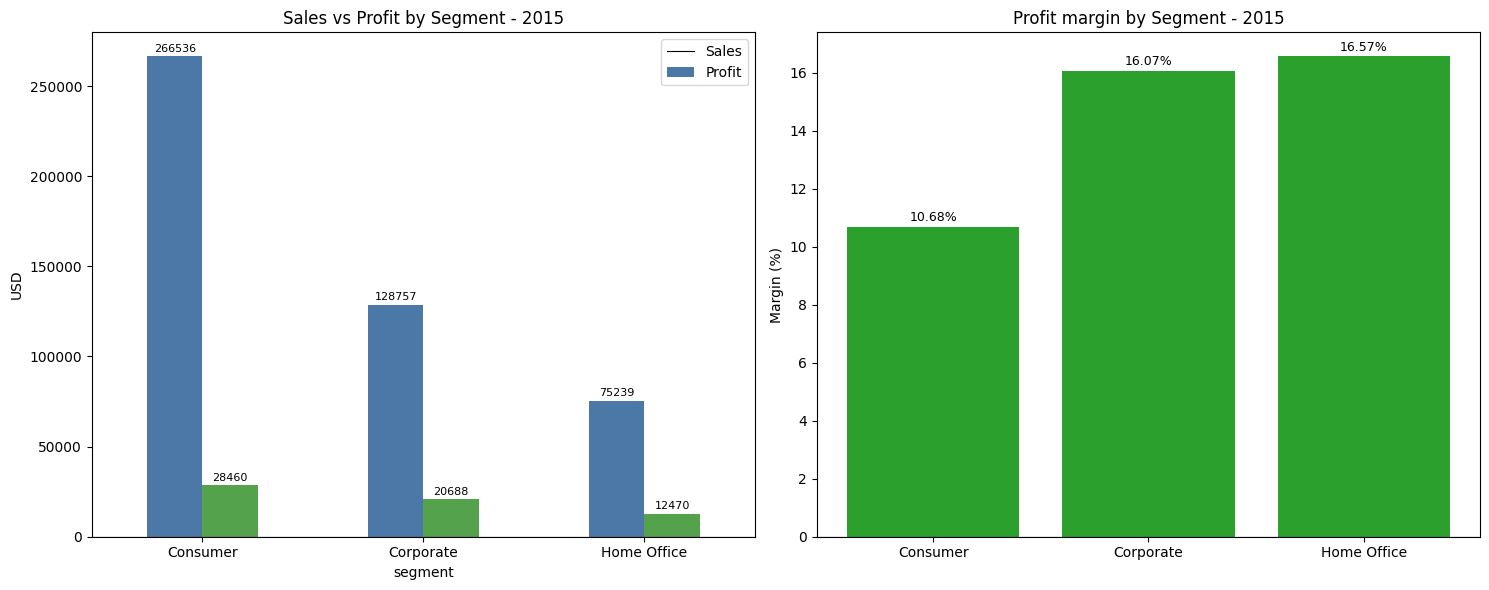

In [108]:
# ===== 6. Customer Segment analysis (2015) =====
# Compare the 3 segments: Consumer / Corporate / Home Office
segment_2015 = (
    df_2015.groupby("segment")
    .agg(orders=("order_id", "nunique"),
         customers=("customer_id", "nunique"),
         total_sales=("sales", "sum"),
         total_profit=("profit", "sum"))
    .assign(margin_pct=lambda x: (x["total_profit"] / x["total_sales"] * 100).round(2))
    .sort_values("total_sales", ascending=False)
)
print(segment_2015)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Sales vs Profit by segment (value labels on bars) ---
segment_2015[["total_sales", "total_profit"]].plot(
    kind="bar", ax=axes[0], color=["#4C78A8", "#54A24B"]
)
axes[0].set_title("Sales vs Profit by Segment - 2015")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=0)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].legend(["Sales", "Profit"])
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", padding=2, fontsize=8)

# --- Right: Profit margin % by segment (green = profit, red = loss) ---
m = segment_2015["margin_pct"]
axes[1].bar(m.index, m.values,
            color=["#2ca02c" if v >= 0 else "#d62728" for v in m.values])
axes[1].set_title("Profit margin by Segment - 2015")
axes[1].set_ylabel("Margin (%)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].bar_label(axes[1].containers[0], fmt="%.2f%%", padding=2, fontsize=9)

plt.tight_layout()
plt.show()

===== TOP 10 sản phẩm lãi nhiều nhất 2015 =====
product_name
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind              7498.8410
Zebra ZM400 Thermal Label Printer                                                        3343.5360
Canon PC1060 Personal Laser Copier                                                       2680.9617
Canon PC940 Copier                                                                       1966.4563
Plantronics Savi W720 Multi-Device Wireless Headset System                               1535.8980
Sanyo Counter Height Refrigerator with Crisper, 3.6 Cubic Foot, Stainless Steel/Black    1194.4296
Sharp AL-1530CS Digital Copier                                                           1014.9797
Plantronics CS510 - Over-the-Head monaural Wireless Headset System                        979.9515
Hon Olson Stacker Chairs                                                                  937.3212
Sharp 1540cs Digital Laser Copier               

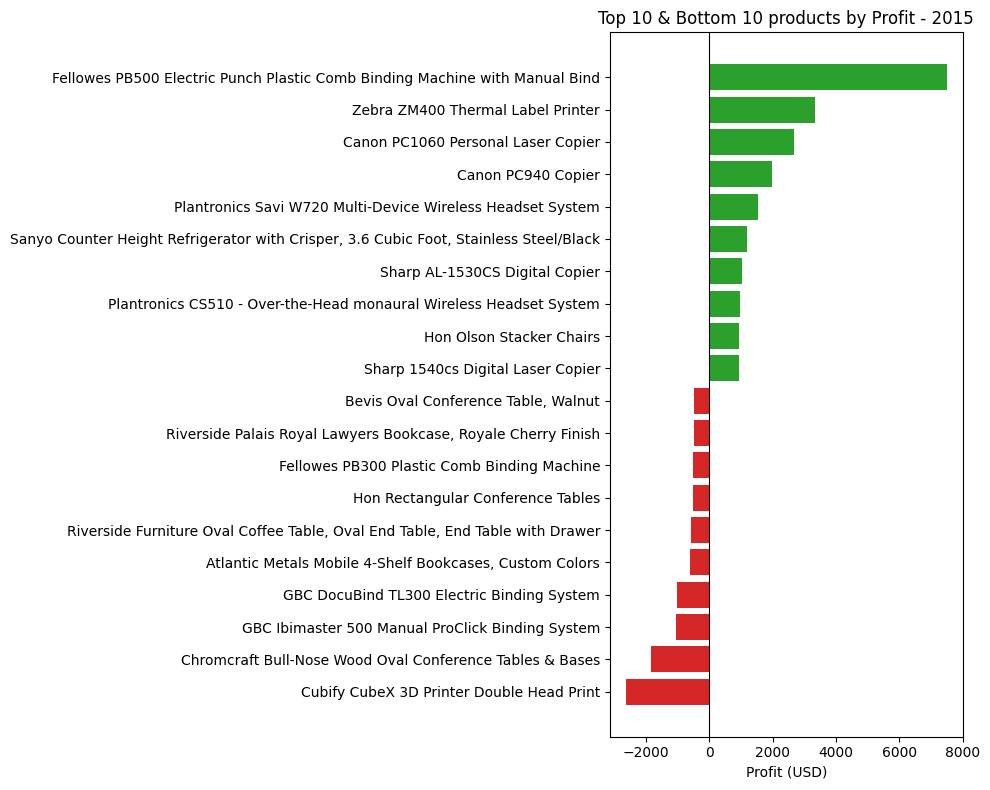

In [109]:
# ===== 7. Top / Bottom products by Profit (2015) =====
prod_profit = (
    df_2015.groupby("product_name")["profit"].sum().sort_values(ascending=False)
)

print("===== TOP 10 sản phẩm lãi nhiều nhất 2015 =====")
print(prod_profit.head(10), "\n")
print("===== TOP 10 sản phẩm lỗ nặng nhất 2015 =====")
print(prod_profit.tail(10))

# Chart: ghép top 10 + bottom 10 vào 1 biểu đồ thanh ngang
top_bottom = pd.concat([prod_profit.head(10), prod_profit.tail(10)]).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(
    top_bottom.index, top_bottom.values,
    color=["#2ca02c" if v >= 0 else "#d62728" for v in top_bottom.values]
)
plt.axvline(0, color="black", linewidth=0.8)   # mốc 0 ngăn lãi / lỗ
plt.title("Top 10 & Bottom 10 products by Profit - 2015")
plt.xlabel("Profit (USD)")
plt.tight_layout()
plt.show()

      total_sales  total_profit  orders  margin_pct
year                                               
2014  484247.4981    49543.9741     969       10.23
2015  470532.5090    61618.6037    1038       13.10 

Sales growth  2014->2015: -2.83%
Profit growth 2014->2015: +24.37%


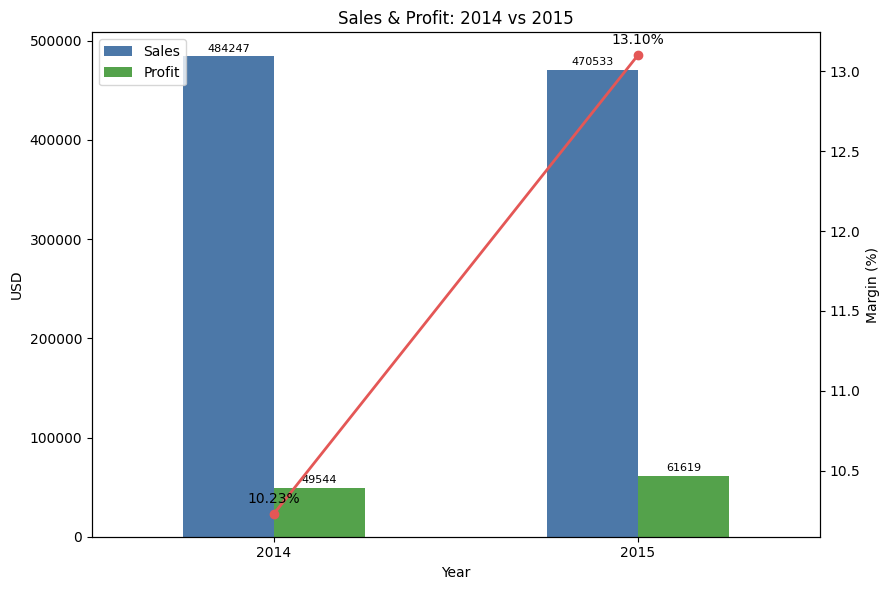

In [110]:
# ===== 8. Year-over-Year comparison (2014 vs 2015) =====
yoy = (
    df[df['order_date'].dt.year.isin([2014, 2015])]
    .assign(year=lambda x: x['order_date'].dt.year)
    .groupby("year")
    .agg(total_sales=("sales", "sum"),
         total_profit=("profit", "sum"),
         orders=("order_id", "nunique"))
)
yoy["margin_pct"] = (yoy["total_profit"] / yoy["total_sales"] * 100).round(2)
print(yoy, "\n")

# Growth % 2014 -> 2015
growth_sales  = (yoy.loc[2015, "total_sales"]  / yoy.loc[2014, "total_sales"]  - 1) * 100
growth_profit = (yoy.loc[2015, "total_profit"] / yoy.loc[2014, "total_profit"] - 1) * 100
print(f"Sales growth  2014->2015: {growth_sales:+.2f}%")
print(f"Profit growth 2014->2015: {growth_profit:+.2f}%")

# --- Chart: Sales & Profit bars (value labels) + margin % line on right axis ---
yoy.index = yoy.index.astype(str)   # year as category label

fig, ax = plt.subplots(figsize=(9, 6))
yoy[["total_sales", "total_profit"]].plot(kind="bar", ax=ax, color=["#4C78A8", "#54A24B"])
ax.set_title("Sales & Profit: 2014 vs 2015")
ax.set_xlabel("Year")
ax.set_ylabel("USD")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Sales", "Profit"], loc="upper left")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=2, fontsize=8)

ax2 = ax.twinx()
ax2.plot(range(len(yoy)), yoy["margin_pct"], color="#E45756", marker="o", linewidth=2)
ax2.set_ylabel("Margin (%)")
for i, v in enumerate(yoy["margin_pct"]):
    ax2.annotate(f"{v:.2f}%", (i, v), textcoords="offset points", xytext=(0, 8), ha="center")

plt.tight_layout()
plt.show()